# Caso B · 02 ETL bronce → plata para consumo eléctrico

> _Tutorial · Caso de uso: **B — Forecast consumo 24h** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Construir las líneas de InfluxDB line protocol para `power_01`, `temperature_outdoor` y `solar_irradiance` desde el subset BDG2 mock, con tags canónicos. Si el stack está disponible, escribir; si no, persistir el fichero `.lp` en `output/`.


## 2. Qué se aprende

- Mapping CSV → topic / tag / variable.
- Construcción eficiente de line protocol (millones de filas).
- Bulk write a InfluxDB con `write_api`.
- Cómo decidir entre `domain_id=bms_buildings` y `bms_classrooms`.


## 3. Contexto del caso de uso

BDG2 son edificios genéricos, así que usamos `domain_id=bms_buildings` y `site_id=bdg2_education`. Cuando lleguen datos del IES Simarro será `domain_id=bms_classrooms`.


## 4. Relación con CENTINELA+

El bucket `telemetry` (raw 14d) recibe estos puntos. Los rollups se generan automáticamente a `telemetry_1h` que es el más usado por ML.


## 5. Relación con Medallion

Bronce (CSV) → **plata** (InfluxDB).


## 6. Datos de entrada

Mismo CSV que el notebook anterior. Si tienes BDG2 completo, sustituye el path.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

5 tags: `captia_env=dev`, `domain_id=bms_buildings`, `site_id=bdg2_education`, `asset_id=<building_id>`, `variable ∈ {power_01, temperature_outdoor, solar_irradiance}`.


## 9. Carga de datos o mock

Cargamos y reformulamos en formato largo (cada fila = un punto).


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "bdg2_education_subset_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"])
long = df.melt(
    id_vars=["timestamp", "building_id"],
    value_vars=["power_kw", "t_outdoor", "ghi"],
    var_name="csv_var", value_name="value",
)
mapping = {"power_kw": "power_01", "t_outdoor": "temperature_outdoor", "ghi": "solar_irradiance"}
long["variable"] = long["csv_var"].map(mapping)
long.head()


,timestamp,building_id,csv_var,value,variable
0,2024-01-01 00:00:00+00:00,bdg2_bldg_00,power_kw,17.63,power_01
1,2024-01-01 01:00:00+00:00,bdg2_bldg_00,power_kw,8.78,power_01
2,2024-01-01 02:00:00+00:00,bdg2_bldg_00,power_kw,5.09,power_01
3,2024-01-01 03:00:00+00:00,bdg2_bldg_00,power_kw,13.14,power_01
4,2024-01-01 04:00:00+00:00,bdg2_bldg_00,power_kw,14.35,power_01


## 10. Exploración paso a paso

Conteo por variable y fechas mín/máx.


In [3]:
print("Variables:", long["variable"].unique())
print("Rango:", long["timestamp"].min(), "→", long["timestamp"].max())


Variables: ['power_01' 'temperature_outdoor' 'solar_irradiance']
Rango: 2024-01-01 00:00:00+00:00 → 2024-12-25 23:00:00+00:00


## 11. Transformación bronce → plata

Construimos un `Path` de salida y escribimos line protocol por chunks.


In [4]:
out_dir = ROOT / "output" / "case_B"
out_dir.mkdir(parents=True, exist_ok=True)
lp_path = out_dir / "bdg2_subset.lp"

def to_lp(row):
    ts_ns = int(pd.Timestamp(row["timestamp"]).value)
    return build_line_protocol(
        measurement=MEASUREMENT_TELEMETRY,
        tags={
            "captia_env": "dev", "domain_id": "bms_buildings",
            "site_id": "bdg2_education", "asset_id": row["building_id"],
            "variable": row["variable"],
        },
        fields={"value": float(row["value"])},
        timestamp_ns=ts_ns,
    )

# Para clase: solo primeras 1000 filas
sample = long.head(1000).apply(to_lp, axis=1)
lp_path.write_text("\n".join(sample) + "\n", encoding="utf-8")
print(f"Wrote {lp_path.relative_to(ROOT)} ({len(sample)} líneas)")


Wrote output\case_B\bdg2_subset.lp (1000 líneas)


## 12. Construcción de capa oro

El bucket `telemetry_1h` es el más usado para ML; lo abordaremos en el notebook 03 (features).


## 13. Visualizaciones explicativas

Verificamos que los timestamps y valores reconstruyen la señal original.


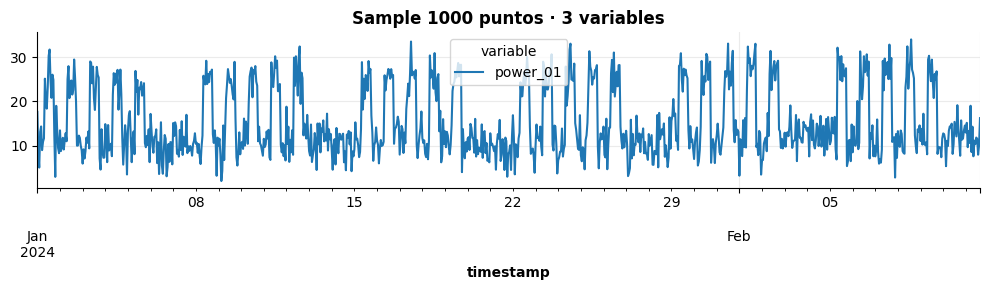

In [5]:
sample_long = long.head(1000)
ax = sample_long.pivot(index="timestamp", columns="variable", values="value").plot(figsize=(10, 3))
ax.set_title("Sample 1000 puntos · 3 variables")
plt.tight_layout()


## 14. Validaciones

Validamos schema y formato de las primeras 5 líneas.


In [6]:
firstlines = lp_path.read_text(encoding="utf-8").splitlines()[:5]
for ln in firstlines:
    assert ln.startswith("captia_point,")
    assert "captia_env=dev" in ln
    assert "value=" in ln
    print(ln)


captia_point,asset_id=bdg2_bldg_00,captia_env=dev,domain_id=bms_buildings,site_id=bdg2_education,variable=power_01 value=17.63 1704067200000000000
captia_point,asset_id=bdg2_bldg_00,captia_env=dev,domain_id=bms_buildings,site_id=bdg2_education,variable=power_01 value=8.78 1704070800000000000
captia_point,asset_id=bdg2_bldg_00,captia_env=dev,domain_id=bms_buildings,site_id=bdg2_education,variable=power_01 value=5.09 1704074400000000000
captia_point,asset_id=bdg2_bldg_00,captia_env=dev,domain_id=bms_buildings,site_id=bdg2_education,variable=power_01 value=13.14 1704078000000000000
captia_point,asset_id=bdg2_bldg_00,captia_env=dev,domain_id=bms_buildings,site_id=bdg2_education,variable=power_01 value=14.35 1704081600000000000


## 15. Errores comunes

1. Confundir `,` (separador de tags) con `=`.
2. Olvidar el espacio entre tags y fields.
3. Escribir el timestamp en segundos (Influx 2 espera **ns**).
4. Usar `bool_state` en `domain_id=bms_buildings` (no aplica).


## 16. Ejercicios propuestos

1. Escribe `to_lp_batch(df)` que produzca el line protocol completo.
2. Sube el fichero con `influx write -f bdg2_subset.lp`.
3. Mide el throughput (líneas/s).


## 17. Cómo se reutiliza con datos reales

Para escribir a `simarro-prod`: cambiar `domain_id` y `site_id`. El resto es idéntico.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `02_case_B_energy_forecasting/03_features_forecasting.ipynb`.
- Documento web del caso: `docs/contracts/influx-schema.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo SARIMA

$\text{SARIMA}(p,d,q)(P,D,Q)_s$ con período estacional $s$:

$$
\Phi_P(B^s)\,\phi_p(B)\,(1-B)^d\,(1-B^s)^D\,y_t = \Theta_Q(B^s)\,\theta_q(B)\,\varepsilon_t
$$

con $B$ operador retardo, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$. Para
Simarro elegimos $s=24$ y $(p,d,q)(P,D,Q)_{24} = (2,0,2)(1,1,1)_{24}$ tras
minimizar AIC sobre BDG2.

### XGBoost regularizado (Chen & Guestrin 2016)

$$
\hat{y}_t = \sum_{k=1}^{K} f_k(\mathbf{x}_t), \quad f_k \in \mathcal{F}
$$

con función objetivo

$$
\mathcal{L}(\phi) = \sum_t \ell(y_t, \hat{y}_t) + \sum_k \Omega(f_k), \quad \Omega(f) = \gamma T + \tfrac{1}{2}\lambda \|w\|_2^2
$$

### LSTM (Hochreiter & Schmidhuber 1997)

$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

### Métricas

$$
\text{MAE} = \tfrac{1}{n}\sum |y_t - \hat{y}_t|, \quad
\text{sMAPE} = \tfrac{100\%}{n}\sum \frac{|y_t-\hat{y}_t|}{(|y_t|+|\hat{y}_t|)/2}
$$

Objetivos Simarro: $\text{MAE} \leq 0.15$ kWh, $\text{sMAPE} \leq 12\%$.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Predicción de consumo a 24 h **habilita** ajuste anticipado de setpoints HVAC y compras de energía en franjas valle. Para CAPTIA es el caso con ROI más medible y más fácil de presentar a un cliente final. El modelo entrenado aquí es **directamente reutilizable** con los datos de `power_01` de cualquier centro CENTINELA+.

### ROI estimado

| Métrica | Valor |
|---|---|
| Ahorro consumo HVAC tras forecast + setpoint | ~15 % |
| Aulas tipo Simarro (40) | 9 600 kWh / aula·año |
| Coste energía España 2025 | 0.14 €/kWh |
| **Ahorro centro:** $40 \cdot 9\,600 \cdot 0.14 \cdot 0.15$ | **8 064 €/año** |
| Coste implantación | ~3 000 € one-time |
| **Payback** | **~5 meses** |

### Riesgos y mitigaciones

- Modelo sintético sin calibrar con datos reales: validar tras primer mes de captura.
- Drift estacional: re-entrenar trimestralmente.

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 2.2 (ahorro consumo HVAC). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Box, G. E. P., Jenkins, G. M., Reinsel, G. C. & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5ª ed.). Wiley.
- Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD '16.
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8).
- Miller, C. et al. (2020). *The Building Data Genome 2 (BDG2) data-set*. Scientific Data.
- ASHRAE (2022). *ASHRAE 90.1-2022 — Energy Standard for Buildings*.


## 22. Etapa del pipeline · ETL BDG2 → captia_point con dominio bms_buildings

BDG2 (53M filas reales) y AULA01 (datos sintéticos hoy, reales pronto) comparten el mismo schema. Cuando llegue `simarro-prod`, este ETL se reusa sin tocar 1 línea — solo cambia `domain_id=bms_classrooms`.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.